# American Options and the Binomial Tree

This notebook adds early-exercise valuation to the pricing engine using a Cox–Ross–Rubinstein (CRR) recombining tree. It focuses on three checks:

1. European tree prices converge toward Black–Scholes values.
2. A non-dividend-paying American call has no early-exercise premium.
3. An American put can be worth more than its European equivalent because exercise before maturity may be optimal.


In [1]:
import os
import sys
sys.path.append(os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.binomial_tree import price_binomial_option
from src.derivatives import EuropeanCall, EuropeanPut, AmericanCall, AmericanPut
from src.yieldcurve import YieldCurve

## Market inputs

The example uses an at-the-money one-year option and a maturity-dependent continuously compounded zero rate. The same market inputs are supplied to the analytical and tree-based contracts.

In [2]:
S0 = 100.0
K = 100.0
T = 1.0
sigma = 0.20

maturities = [0.5, 1.0, 2.0, 3.0]
zero_rates = [0.03, 0.032, 0.035, 0.038]
yield_curve = YieldCurve(maturities, zero_rates)
r = yield_curve.get_zero_rate(T)

print(f'Continuously compounded one-year rate: {r:.2%}')

Continuously compounded one-year rate: 3.20%


## CRR convergence toward Black–Scholes

A European payoff can also be valued on the CRR tree by suppressing early exercise. As the number of time steps increases, the discrete model should converge toward the continuous-time Black–Scholes benchmark.

In [3]:
european_call = EuropeanCall(S0, K, T, sigma, yield_curve)
european_put = EuropeanPut(S0, K, T, sigma, yield_curve)

step_counts = [10, 25, 50, 100, 250, 500, 1000]
convergence_rows = []

for steps in step_counts:
    tree_call = price_binomial_option(
        S0, K, r, sigma, T, steps,
        option_type='call', exercise_style='european'
    )
    tree_put = price_binomial_option(
        S0, K, r, sigma, T, steps,
        option_type='put', exercise_style='european'
    )
    convergence_rows.append({
        'Steps': steps,
        'Tree call': tree_call,
        'Call error': tree_call - european_call.price(),
        'Tree put': tree_put,
        'Put error': tree_put - european_put.price(),
    })

convergence = pd.DataFrame(convergence_rows)
convergence

,Steps,Tree call,Call error,Tree put,Put error
0,10,9.318960,-0.195644,6.169618,-0.195644
1,25,9.589839,0.075236,6.440497,0.075236
2,50,9.475020,-0.039583,6.325679,-0.039583
3,100,9.494786,-0.019817,6.345444,-0.019817
4,250,9.506670,-0.007933,6.357328,-0.007933
5,500,9.510636,-0.003967,6.361294,-0.003967
6,1000,9.512619,-0.001984,6.363277,-0.001984


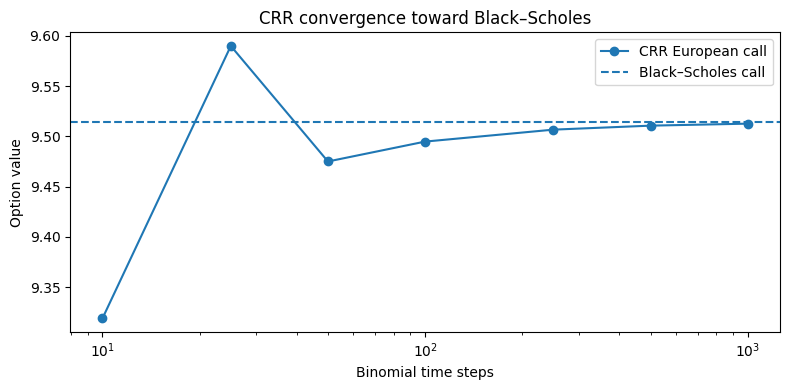

In [4]:
plt.figure(figsize=(8, 4))
plt.plot(convergence['Steps'], convergence['Tree call'], marker='o', label='CRR European call')
plt.axhline(european_call.price(), linestyle='--', label='Black–Scholes call')
plt.xscale('log')
plt.xlabel('Binomial time steps')
plt.ylabel('Option value')
plt.title('CRR convergence toward Black–Scholes')
plt.legend()
plt.tight_layout()
plt.show()

The tree exhibits the usual odd–even oscillation, but the error narrows as the time grid is refined. At 1,000 steps, the tree and analytical values are already very close.

## American early-exercise premium

The American tree compares continuation and immediate exercise at every node. For a put, receiving the strike earlier can be valuable. For a call on a non-dividend-paying stock, exercising early sacrifices time value without receiving an offsetting dividend, so the American and European tree values should coincide.

In [5]:
american_call = AmericanCall(S0, K, T, sigma, yield_curve, steps=500)
american_put = AmericanPut(S0, K, T, sigma, yield_curve, steps=500)

european_tree_call = price_binomial_option(
    S0, K, r, sigma, T, 500,
    option_type='call', exercise_style='european'
)
european_tree_put = price_binomial_option(
    S0, K, r, sigma, T, 500,
    option_type='put', exercise_style='european'
)

premium_table = pd.DataFrame([
    {
        'Contract': 'Call',
        'European tree': european_tree_call,
        'American tree': american_call.price(),
        'Early-exercise premium': american_call.price() - european_tree_call,
    },
    {
        'Contract': 'Put',
        'European tree': european_tree_put,
        'American tree': american_put.price(),
        'Early-exercise premium': american_put.price() - european_tree_put,
    },
])
premium_table

,Contract,European tree,American tree,Early-exercise premium
0,Call,9.510636,9.510636,0.000000
1,Put,6.361294,6.671183,0.309889


The call premium is zero to numerical precision, which is an important implementation check. The American put is more valuable because the holder can exercise in sufficiently low-price states before maturity.

## American put exercise boundary

For each time layer, the boundary is the highest underlying price at which immediate put exercise is preferred to continuation. Dates with no optimal early-exercise nodes are omitted.

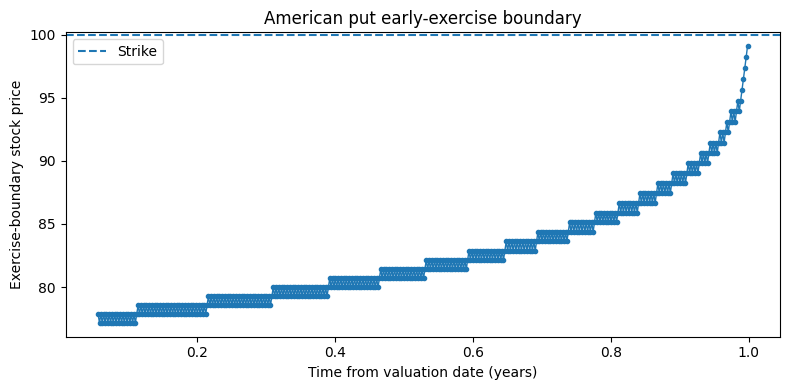

Early exercise appears at 472 of 500 pre-expiry time layers.


In [6]:
put_analysis = american_put.tree_analysis()
valid = np.isfinite(put_analysis.exercise_boundary)

plt.figure(figsize=(8, 4))
plt.plot(
    put_analysis.time_grid[valid],
    put_analysis.exercise_boundary[valid],
    marker='.',
    linewidth=1,
)
plt.axhline(K, linestyle='--', label='Strike')
plt.xlabel('Time from valuation date (years)')
plt.ylabel('Exercise-boundary stock price')
plt.title('American put early-exercise boundary')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Early exercise appears at {valid.sum()} of {american_put.steps} pre-expiry time layers.')

The boundary generally rises toward the strike as expiry approaches. With less remaining optionality, a smaller intrinsic-value advantage is required to justify exercise. The small saw-tooth pattern is a discretisation effect of the recombining lattice.

## Price sensitivities

American Greeks are calculated by bumping each input and rebuilding the tree. They are numerical estimates rather than closed-form values, so their stability depends on both the bump size and the number of tree steps.

In [7]:
greek_table = pd.DataFrame(
    [
        {'Option': 'American call', 'Price': american_call.price(), **american_call.greeks()},
        {'Option': 'American put', 'Price': american_put.price(), **american_put.greeks()},
    ]
).set_index('Option')

greek_table

,Price,delta,gamma,vega,theta,rho
Option,,,,,,
American call,9.510636,0.602518,0.020871,38.549035,-5.478627,50.741196
American put,6.671183,-0.424619,0.022600,38.465117,-2.736867,-34.674851


The call has positive delta and rho, while the put has negative delta and rho. Both have positive vega in this example. The American put's sensitivities incorporate the possibility that parameter changes also move the optimal exercise region.

## Main results

- The CRR model converges toward Black–Scholes when exercise is restricted to maturity.
- The non-dividend-paying American call has no early-exercise premium.
- The American put carries a positive early-exercise premium.
- Backward induction produces both a price and an economically interpretable exercise boundary.
- The common derivative interface now supplies price, delta, gamma, vega, theta and rho for European, Asian and American contracts.
